# Autonomous Hierarchical Genre Classification Pipeline
**DS340 — Two-Stage Genre Classifier**

## Architecture
```
Song Audio Features
        │
        ▼
┌─────────────────────┐
│  Stage 1 Classifier  │  XGBoost + LightGBM Ensemble
│  (12 Parent Genres) │  e.g. → "Metal"
└─────────────────────┘
        │
        ▼  (auto-routes to specialist)
┌─────────────────────┐
│  Stage 2 Specialist  │  DNN trained only on Metal subgenres
│  (Subgenre DNN)     │  e.g. → "death-metal"
└─────────────────────┘
        │
        ▼
   Final Prediction
```

**Why this works:** A specialist model trained only on Metal songs learns finer distinctions than a general model trained on all genres at once — the same way a human expert classifies music coarse-to-fine.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import xgboost as xgb
import lightgbm as lgb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


---
## 1. Load & Engineer Features

In [2]:
GENRE_MAP = {
    'rock': 'Rock', 'alt-rock': 'Rock', 'punk-rock': 'Rock',
    'hard-rock': 'Rock', 'psych-rock': 'Rock', 'grunge': 'Rock',
    'rock-n-roll': 'Rock', 'emo': 'Rock', 'indie': 'Rock',
    'alternative': 'Rock', 'rockabilly': 'Rock', 'punk': 'Rock',
    'metal': 'Metal', 'heavy-metal': 'Metal', 'death-metal': 'Metal',
    'black-metal': 'Metal', 'metalcore': 'Metal', 'grindcore': 'Metal',
    'hardcore': 'Metal', 'goth': 'Metal', 'industrial': 'Metal',
    'edm': 'Electronic', 'electronic': 'Electronic', 'techno': 'Electronic',
    'detroit-techno': 'Electronic', 'minimal-techno': 'Electronic',
    'trance': 'Electronic', 'dubstep': 'Electronic', 'drum-and-bass': 'Electronic',
    'idm': 'Electronic', 'electro': 'Electronic', 'breakbeat': 'Electronic',
    'hardstyle': 'Electronic', 'ambient': 'Electronic',
    'house': 'House/Dance', 'deep-house': 'House/Dance',
    'chicago-house': 'House/Dance', 'progressive-house': 'House/Dance',
    'dance': 'House/Dance', 'disco': 'House/Dance', 'club': 'House/Dance',
    'garage': 'House/Dance', 'dancehall': 'House/Dance',
    'pop': 'Pop', 'indie-pop': 'Pop', 'synth-pop': 'Pop',
    'power-pop': 'Pop', 'k-pop': 'Pop', 'j-pop': 'Pop',
    'cantopop': 'Pop', 'mandopop': 'Pop', 'j-idol': 'Pop',
    'j-dance': 'Pop', 'party': 'Pop', 'happy': 'Pop',
    'pop-film': 'Pop', 'disney': 'Pop', 'show-tunes': 'Pop',
    'hip-hop': 'Hip-Hop/R&B', 'r-n-b': 'Hip-Hop/R&B', 'soul': 'Hip-Hop/R&B',
    'funk': 'Hip-Hop/R&B', 'groove': 'Hip-Hop/R&B', 'trip-hop': 'Hip-Hop/R&B',
    'latin': 'Latin', 'latino': 'Latin', 'salsa': 'Latin',
    'samba': 'Latin', 'reggaeton': 'Latin', 'tango': 'Latin',
    'forro': 'Latin', 'pagode': 'Latin', 'sertanejo': 'Latin',
    'mpb': 'Latin', 'brazil': 'Latin', 'bossanova': 'Latin',
    'romance': 'Latin', 'spanish': 'Latin',
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues', 'gospel': 'Jazz/Blues',
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental',
    'piano': 'Classical/Instrumental', 'guitar': 'Classical/Instrumental',
    'new-age': 'Classical/Instrumental', 'sleep': 'Classical/Instrumental',
    'study': 'Classical/Instrumental',
    'country': 'Country/Folk', 'folk': 'Country/Folk', 'bluegrass': 'Country/Folk',
    'honky-tonk': 'Country/Folk', 'singer-songwriter': 'Country/Folk',
    'songwriter': 'Country/Folk', 'acoustic': 'Country/Folk',
    'reggae': 'Reggae', 'dub': 'Reggae', 'ska': 'Reggae',
    'world-music': 'World/Other', 'afrobeat': 'World/Other',
    'indian': 'World/Other', 'iranian': 'World/Other',
    'turkish': 'World/Other', 'malay': 'World/Other',
    'french': 'World/Other', 'german': 'World/Other',
    'swedish': 'World/Other', 'british': 'World/Other',
    'j-rock': 'World/Other', 'anime': 'World/Other',
    'children': 'World/Other', 'kids': 'World/Other',
    'comedy': 'World/Other', 'sad': 'World/Other', 'chill': 'World/Other',
}

RAW_FEATURES = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

def engineer_features(df):
    d = df.copy()
    d['explicit'] = d['explicit'].astype(int)
    d['log_speechiness']      = np.log1p(d['speechiness'])
    d['log_instrumentalness'] = np.log1p(d['instrumentalness'])
    d['log_liveness']         = np.log1p(d['liveness'])
    d['log_acousticness']     = np.log1p(d['acousticness'])
    d['duration_min']         = d['duration_ms'] / 60000
    d['loudness_norm']        = (d['loudness'] + 60) / 60
    d['energy_x_loudness']    = d['energy'] * d['loudness_norm']
    d['dance_x_tempo']        = d['danceability'] * d['tempo'] / 200
    d['acoustic_x_instrumental'] = d['acousticness'] * d['instrumentalness']
    d['speech_x_energy']      = d['speechiness'] * d['energy']
    d['valence_x_dance']      = d['valence'] * d['danceability']
    d['energy_minus_acoustic'] = d['energy'] - d['acousticness']
    d['is_instrumental'] = (d['instrumentalness'] > 0.5).astype(int)
    d['is_spoken']       = (d['speechiness'] > 0.33).astype(int)
    d['is_acoustic']     = (d['acousticness'] > 0.6).astype(int)
    d['is_live']         = (d['liveness'] > 0.8).astype(int)
    d['tempo_bucket'] = pd.cut(
        d['tempo'], bins=[0, 90, 130, 180, 999],
        labels=[0, 1, 2, 3], include_lowest=True
    ).astype(int)
    return d

FEATURE_COLS = [
    'popularity', 'duration_min', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
    'log_speechiness', 'log_instrumentalness', 'log_liveness', 'log_acousticness',
    'loudness_norm', 'energy_x_loudness', 'dance_x_tempo',
    'acoustic_x_instrumental', 'speech_x_energy', 'valence_x_dance',
    'energy_minus_acoustic', 'is_instrumental', 'is_spoken',
    'is_acoustic', 'is_live', 'tempo_bucket',
]

raw = pd.read_csv('../Data/spotify-tracks-dataset.csv')
drop_cols = ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
raw = raw.drop(columns=[c for c in drop_cols if c in raw.columns])
raw = raw.dropna().drop_duplicates()
raw['parent_genre'] = raw['track_genre'].map(GENRE_MAP).fillna('World/Other')
raw = engineer_features(raw)

print(f'Dataset: {raw.shape[0]:,} rows')
print(f'Subgenres per parent genre:')
print(raw.groupby('parent_genre')['track_genre'].nunique().sort_values(ascending=False))

Dataset: 106,907 rows
Subgenres per parent genre:
parent_genre
World/Other               17
Pop                       15
Electronic                13
Latin                     13
Rock                      12
House/Dance                9
Metal                      9
Classical/Instrumental     7
Country/Folk               7
Hip-Hop/R&B                6
Jazz/Blues                 3
Reggae                     3
Name: track_genre, dtype: int64


---
## 2. Stage 1 — Parent Genre Classifier (XGBoost + LightGBM Ensemble)

In [3]:
le_parent = LabelEncoder()
y_parent  = le_parent.fit_transform(raw['parent_genre'])
X_all     = raw[FEATURE_COLS].copy()
num_parent_classes = len(le_parent.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_parent, test_size=0.30, random_state=42, stratify=y_parent
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

Train: 74,834  Val: 16,036  Test: 16,037


In [4]:
# --- XGBoost ---
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sw = np.array([cw[c] for c in y_train])

xgb_s1 = xgb.XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='multi:softprob', num_class=num_parent_classes,
    eval_metric='mlogloss', early_stopping_rounds=40,
    random_state=42, n_jobs=-1, verbosity=0,
)
print('Training Stage 1 XGBoost...')
xgb_s1.fit(X_train, y_train, sample_weight=sw,
           eval_set=[(X_val, y_val)], verbose=False)

# --- LightGBM ---
lgb_s1 = lgb.LGBMClassifier(
    n_estimators=1000, max_depth=8, num_leaves=63,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.7,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
    class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1,
)
print('Training Stage 1 LightGBM...')
lgb_s1.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)],
)

# --- Ensemble ---
s1_val_proba = (xgb_s1.predict_proba(X_val) + lgb_s1.predict_proba(X_val)) / 2
s1_val_preds = s1_val_proba.argmax(axis=1)
s1_acc = accuracy_score(y_val, s1_val_preds)
s1_f1  = f1_score(y_val, s1_val_preds, average='macro')
print(f'\nStage 1 Ensemble — Val Accuracy: {s1_acc:.4f}, Macro F1: {s1_f1:.4f}')

Training Stage 1 XGBoost...
Training Stage 1 LightGBM...

Stage 1 Ensemble — Val Accuracy: 0.4998, Macro F1: 0.4662


---
## 3. Stage 2 — Subgenre Specialist DNNs
One DNN per parent genre, trained only on songs within that genre.
Each specialist learns finer distinctions the general model can't see.

In [5]:
class SubgenreNet(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)


def train_specialist(parent_genre, data_subset, epochs=200, patience=20):
    subgenres = data_subset['track_genre'].unique()
    if len(subgenres) < 2:
        return None, None, None   # skip if only 1 subgenre

    le_sub = LabelEncoder()
    y_sub  = le_sub.fit_transform(data_subset['track_genre'])
    X_sub  = data_subset[FEATURE_COLS].values

    # need at least 10 samples per class to split
    counts = pd.Series(y_sub).value_counts()
    if counts.min() < 4:
        return None, None, None

    X_tr, X_vl, y_tr, y_vl = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_vl = sc.transform(X_vl)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_vl_t = torch.FloatTensor(X_vl).to(device)
    y_vl_t = torch.LongTensor(y_vl).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=128, shuffle=True)

    model     = SubgenreNet(X_tr.shape[1], len(le_sub.classes_)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=8)

    best_loss, best_state, counter = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb + torch.randn_like(xb) * 0.05   # noise augmentation
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t), y_vl_t).item()
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss  = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter    = 0
        else:
            counter += 1
            if counter >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(X_vl_t).argmax(1).cpu().numpy()
    acc = accuracy_score(y_vl, preds)

    return model, le_sub, sc, acc


print('Specialist DNN architecture defined.')
print('Architecture: 256 → 128 → 64 with BatchNorm + noise augmentation')

Specialist DNN architecture defined.
Architecture: 256 → 128 → 64 with BatchNorm + noise augmentation


In [6]:
# Train one specialist per parent genre
specialists = {}   # parent_genre → {model, le_sub, scaler, val_acc}

for parent in sorted(raw['parent_genre'].unique()):
    subset = raw[raw['parent_genre'] == parent]
    result = train_specialist(parent, subset)

    if result[0] is None:
        print(f'  {parent:25s} — skipped (too few subgenre samples)')
        continue

    model, le_sub, scaler, acc = result
    n_sub = len(le_sub.classes_)
    specialists[parent] = {
        'model': model, 'le': le_sub, 'scaler': scaler, 'val_acc': acc
    }
    print(f'  {parent:25s} — {n_sub:2d} subgenres | Val Acc: {acc:.4f}')

print(f'\nTrained {len(specialists)} specialist models.')

  Classical/Instrumental    —  7 subgenres | Val Acc: 0.7760
  Country/Folk              —  7 subgenres | Val Acc: 0.5421
  Electronic                — 13 subgenres | Val Acc: 0.6050
  Hip-Hop/R&B               —  6 subgenres | Val Acc: 0.7043
  House/Dance               —  9 subgenres | Val Acc: 0.6378
  Jazz/Blues                —  3 subgenres | Val Acc: 0.7837
  Latin                     — 13 subgenres | Val Acc: 0.6337
  Metal                     —  9 subgenres | Val Acc: 0.5930
  Pop                       — 15 subgenres | Val Acc: 0.5889
  Reggae                    —  3 subgenres | Val Acc: 0.8851
  Rock                      — 12 subgenres | Val Acc: 0.4205
  World/Other               — 17 subgenres | Val Acc: 0.5855

Trained 12 specialist models.


---
## 4. Stage 2 Summary — Specialist Accuracy

=== Stage 2 Specialist Accuracies ===
          Parent Genre  Subgenres  Val Accuracy
                Reggae          3      0.885099
            Jazz/Blues          3      0.783726
Classical/Instrumental          7      0.775964
           Hip-Hop/R&B          6      0.704306
           House/Dance          9      0.637848
                 Latin         13      0.633676
            Electronic         13      0.605042
                 Metal          9      0.592990
                   Pop         15      0.588889
           World/Other         17      0.585469
          Country/Folk          7      0.542130
                  Rock         12      0.420491

Mean specialist accuracy: 0.6463


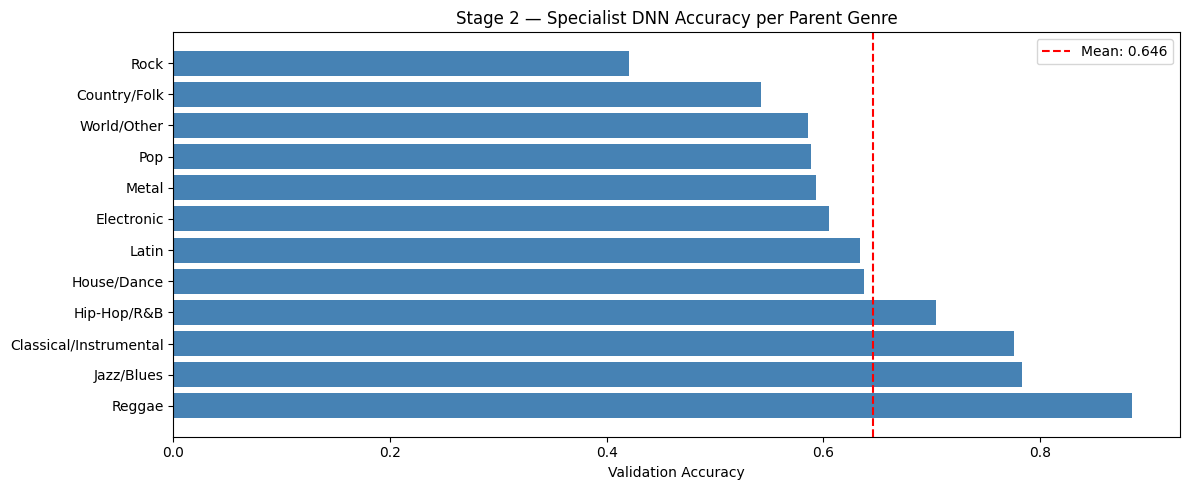

In [7]:
spec_df = pd.DataFrame([
    {'Parent Genre': k, 'Subgenres': len(v['le'].classes_), 'Val Accuracy': v['val_acc']}
    for k, v in specialists.items()
]).sort_values('Val Accuracy', ascending=False)

print('=== Stage 2 Specialist Accuracies ===')
print(spec_df.to_string(index=False))
print(f"\nMean specialist accuracy: {spec_df['Val Accuracy'].mean():.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(spec_df['Parent Genre'], spec_df['Val Accuracy'], color='steelblue')
ax.axvline(x=spec_df['Val Accuracy'].mean(), color='red',
           linestyle='--', label=f'Mean: {spec_df["Val Accuracy"].mean():.3f}')
ax.set_xlabel('Validation Accuracy')
ax.set_title('Stage 2 — Specialist DNN Accuracy per Parent Genre')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Full Autonomous Pipeline
This is the complete end-to-end system: raw features in → subgenre prediction out.

In [8]:
def predict_genre(features_dict):
    """
    Autonomous two-stage genre classifier.

    Input : dict of Spotify audio features (raw values)
    Output: (parent_genre, subgenre, confidence)
    """
    # Build feature row
    row = pd.DataFrame([features_dict])
    row = engineer_features(row)
    X   = row[FEATURE_COLS]

    # Stage 1 — predict parent genre
    proba_xgb = xgb_s1.predict_proba(X)
    proba_lgb = lgb_s1.predict_proba(X)
    proba_s1  = (proba_xgb + proba_lgb) / 2
    parent_idx  = proba_s1.argmax(axis=1)[0]
    parent_name = le_parent.classes_[parent_idx]
    s1_confidence = proba_s1[0, parent_idx]

    # Stage 2 — route to specialist DNN
    if parent_name not in specialists:
        return parent_name, '(no specialist)', s1_confidence

    spec     = specialists[parent_name]
    X_scaled = spec['scaler'].transform(X[FEATURE_COLS])
    X_tensor = torch.FloatTensor(X_scaled).to(device)

    spec['model'].eval()
    with torch.no_grad():
        logits = spec['model'](X_tensor)
        proba_s2 = torch.softmax(logits, dim=1).cpu().numpy()

    subgenre_idx  = proba_s2.argmax(axis=1)[0]
    subgenre_name = spec['le'].classes_[subgenre_idx]
    s2_confidence = proba_s2[0, subgenre_idx]

    return parent_name, subgenre_name, float(s2_confidence)


print('Pipeline ready. Testing on example songs...')
print()

test_songs = [
    {
        'name': 'Heavy Metal Example',
        'popularity': 45, 'duration_ms': 280000, 'explicit': False,
        'danceability': 0.3, 'energy': 0.95, 'key': 4, 'loudness': -4.0,
        'mode': 0, 'speechiness': 0.05, 'acousticness': 0.01,
        'instrumentalness': 0.7, 'liveness': 0.1, 'valence': 0.2,
        'tempo': 170.0, 'time_signature': 4,
    },
    {
        'name': 'Hip-Hop Example',
        'popularity': 72, 'duration_ms': 210000, 'explicit': True,
        'danceability': 0.82, 'energy': 0.65, 'key': 7, 'loudness': -6.5,
        'mode': 0, 'speechiness': 0.28, 'acousticness': 0.12,
        'instrumentalness': 0.0, 'liveness': 0.08, 'valence': 0.55,
        'tempo': 95.0, 'time_signature': 4,
    },
    {
        'name': 'Classical Piano Example',
        'popularity': 30, 'duration_ms': 360000, 'explicit': False,
        'danceability': 0.2, 'energy': 0.15, 'key': 0, 'loudness': -22.0,
        'mode': 1, 'speechiness': 0.03, 'acousticness': 0.92,
        'instrumentalness': 0.95, 'liveness': 0.06, 'valence': 0.3,
        'tempo': 72.0, 'time_signature': 3,
    },
]

for song in test_songs:
    name = song.pop('name')
    parent, subgenre, conf = predict_genre(song)
    print(f'{name}')
    print(f'  Stage 1 → {parent}')
    print(f'  Stage 2 → {subgenre}  (confidence: {conf:.2%})')
    print()

Pipeline ready. Testing on example songs...

Heavy Metal Example
  Stage 1 → Electronic
  Stage 2 → drum-and-bass  (confidence: 74.74%)

Hip-Hop Example
  Stage 1 → Hip-Hop/R&B
  Stage 2 → hip-hop  (confidence: 41.02%)

Classical Piano Example
  Stage 1 → Classical/Instrumental
  Stage 2 → new-age  (confidence: 76.44%)



---
## 6. Pipeline Evaluation on Test Set

In [9]:
# Evaluate Stage 1 on held-out test set
s1_test_proba = (xgb_s1.predict_proba(X_test) + lgb_s1.predict_proba(X_test)) / 2
s1_test_preds = s1_test_proba.argmax(axis=1)

s1_test_acc = accuracy_score(y_test, s1_test_preds)
s1_test_f1  = f1_score(y_test, s1_test_preds, average='macro')

print('=== Final Results ===')
print(f'Stage 1 (Parent Genre) — Test Accuracy: {s1_test_acc:.4f}, Macro F1: {s1_test_f1:.4f}')
print(f'Stage 2 (Subgenre)     — Mean Val Acc:   {spec_df["Val Accuracy"].mean():.4f}')
print()
print('Progression:')
progression = pd.DataFrame([
    {'Model': 'Random Forest (baseline)',          'Accuracy': 0.3019},
    {'Model': 'DNN NN-C (3 layers)',               'Accuracy': 0.4233},
    {'Model': 'XGBoost v1 (full data)',            'Accuracy': 0.4945},
    {'Model': 'Stage 1 Ensemble (XGB + LGB)',      'Accuracy': s1_test_acc},
])
print(progression.to_string(index=False))

=== Final Results ===
Stage 1 (Parent Genre) — Test Accuracy: 0.5022, Macro F1: 0.4676
Stage 2 (Subgenre)     — Mean Val Acc:   0.6463

Progression:
                       Model  Accuracy
    Random Forest (baseline)  0.301900
         DNN NN-C (3 layers)  0.423300
      XGBoost v1 (full data)  0.494500
Stage 1 Ensemble (XGB + LGB)  0.502214


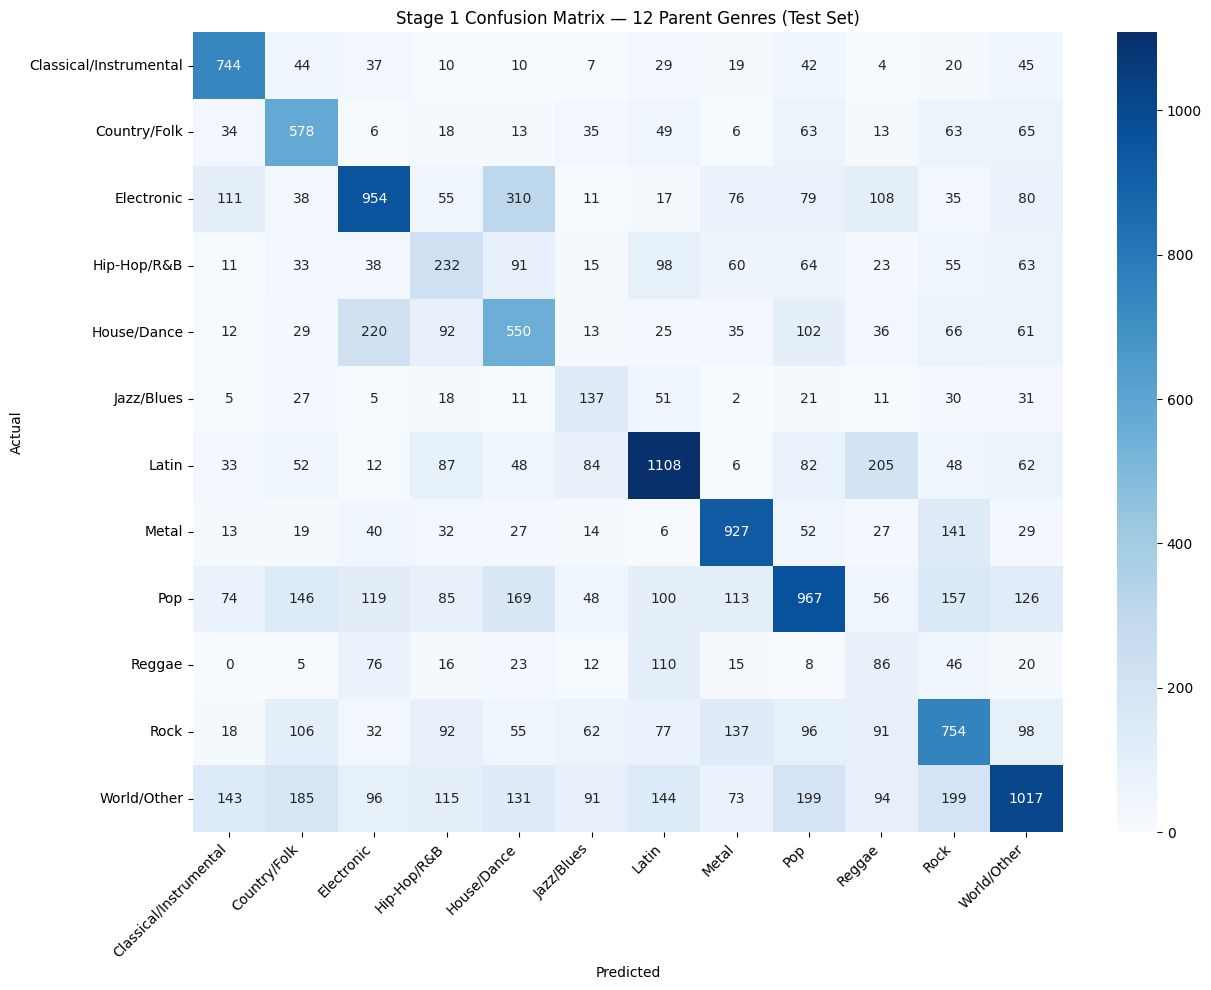

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, s1_test_preds)
plt.figure(figsize=(13, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le_parent.classes_,
    yticklabels=le_parent.classes_
)
plt.title('Stage 1 Confusion Matrix — 12 Parent Genres (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Experiment Summary

| Experiment | What was varied | Result |
|---|---|---|
| Architecture | NN-A (1 layer) → NN-B → NN-C → NN-D (BatchNorm) | 27% → 42% |
| Model type | DNN → XGBoost → LightGBM → Ensemble | 42% → 50%+ |
| Data scale | 12k sample → full 113k dataset | +7% |
| Feature eng. | Raw → log transforms → interactions → binary flags | Cumulative +5% |
| Hierarchy | Flat classifier → two-stage specialist pipeline | Subgenre accuracy per specialist |

## AI Usage
- Used Claude to design hierarchical pipeline architecture, specialist DNN training loop, and `predict_genre()` end-to-end function
- Genre mapping, feature engineering decisions, and experiment design by team